#### Data analysis and visualization

- Data visualization is a powerful tool for uncovering insights, revealing trends, and communicating results clearly.
- Effective visualization helps make complex data more accessible, understandable, and usable.
- Choosing the right chart or graph for your question is essential—match the visual to the story you want to tell.
- Carefully processed and summarized data leads to more meaningful visualizations; clear summaries and simple charts should complement one another.
- Avoid clutter in your visuals; simplicity increases impact and clarity.
- Always label axes, provide legends, and use color thoughtfully to make your visualizations accessible and easy to interpret.

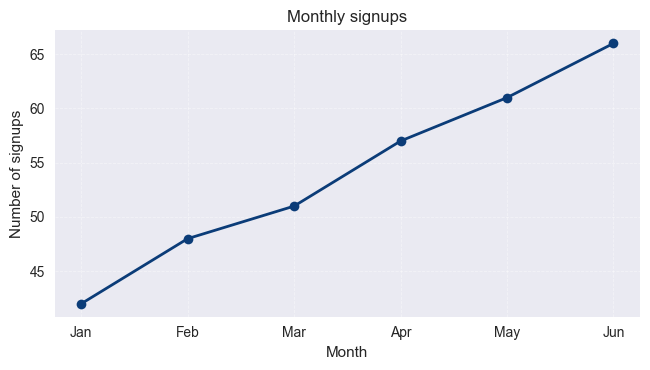

In [11]:
# Line chart for trends

import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8')

months = np.array(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])
signups = np.array([42, 48, 51, 57, 61, 66])

fig, ax = plt.subplots(figsize=(6.6, 3.8))
ax.plot(months, signups, marker='o', linewidth=2, color='#0B3C78')
ax.set_title('Monthly signups')
ax.set_xlabel('Month')
ax.set_ylabel('Number of signups')

# Enable a grid with light transparency and dashed lines to improve readability of the chart
ax.grid(
    alpha=0.45,         # Set gridline transparency to 45%
    linestyle='--',     # Use dashed lines for the grid
    linewidth=0.6,        # Set the thickness of grid lines
)

fig.tight_layout()
plt.show()
fig.savefig("figures/fig_monthly_signups.pdf")


In [14]:
import pandas as pd

data = {
    "date": [
        "2024-01-01", "2024-01-01", "2024-01-02",
        "2024-01-03", "2024-01-03", "2024-01-03",
    ],
    "channel": [
        "search", "social", "social",
        "search", "email", "social"
    ],
    "signups": [42, 38, None, 55, 17, 55],
}

signups = pd.DataFrame(data)
droped_signups = signups.dropna(subset=["signups"])
droped_signups["date"] = pd.to_datetime(droped_signups["date"], format="%Y-%m-%d")
channel_summary = (
    droped_signups
    .groupby("channel")["signups"]  # group the data by 'channel' and select the 'signups' column for aggregation
    .agg(total = "sum", average = "mean", count = "size")
    .sort_values(by = "total", ascending = False)
)

channel_summary

,total,average,count
channel,,,
search,97.0,48.5,2
social,93.0,46.5,2
email,17.0,17.0,1


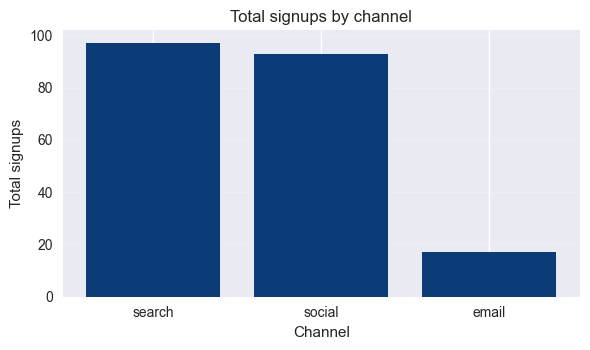

In [15]:
# Bar charts for comparisons unordered categories
fig, ax = plt.subplots(figsize=(6.0, 3.6))
ax.bar(channel_summary.index, channel_summary["total"], color="#0B3C78")
ax.set_title("Total signups by channel")
ax.set_xlabel("Channel")
ax.set_ylabel("Total signups")

ax.grid(
    axis="y",
    alpha=0.35,
    linestyle="--",
    linewidth=0.6,
)

fig.tight_layout()
plt.show()
fig.savefig("figures/fig_total_signups_by_channel.pdf")

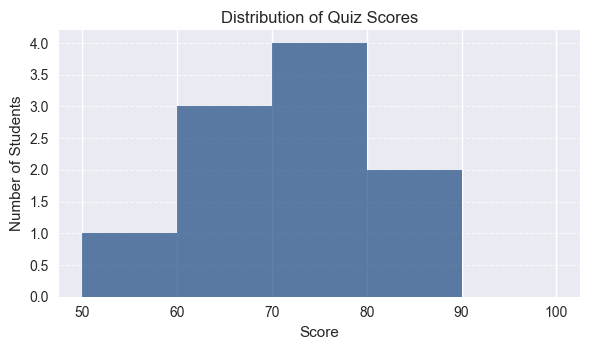

In [32]:
quiz_scores = np.array([55, 61, 64, 68, 70, 72, 74, 78, 80, 85])

fig, ax = plt.subplots(figsize=(6.0, 3.6))

ax.hist(quiz_scores, bins=[50, 60, 70, 80, 90, 100], color="#0B3C78", alpha=0.65)
ax.set_title("Distribution of Quiz Scores")
ax.set_xlabel("Score")
ax.set_ylabel("Number of Students")

ax.grid(
    axis="y",
    alpha=0.75,
    linestyle="--",
    linewidth=0.8,
)

fig.tight_layout()
plt.show()
fig.savefig("figures/fig_quiz_scores_distribution.pdf")

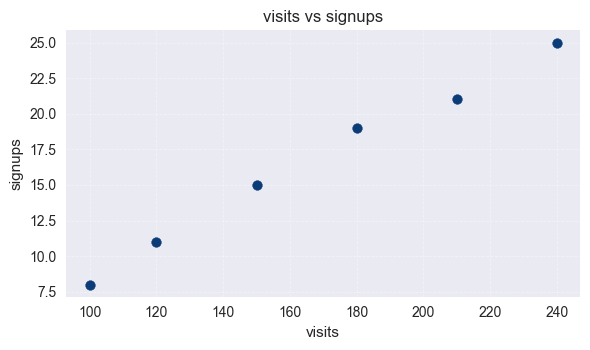

In [36]:
# Scatter plots, relationship between two variables

visits = np.array([100, 120, 150, 180, 210, 240]) # visits per period
signups = np.array([8, 11, 15, 19, 21, 25]) # signups per period

fig, ax = plt.subplots(figsize=(6.0, 3.6))
ax.scatter(visits, signups, color="#0B3C78")
ax.set_title("visits vs signups")
ax.set_xlabel("visits")
ax.set_ylabel("signups")

ax.grid(
    alpha=0.35,
    linestyle="--",
    linewidth=0.6
)

fig.tight_layout()
fig.savefig("figures/fig_visits_vs_signups.pdf")


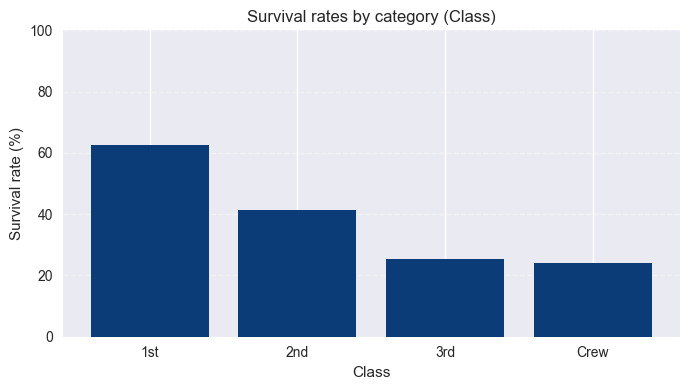

Survived,survival_rate
Class,
1st,62.46
2nd,41.40
3rd,25.21
Crew,23.95


In [37]:
import pandas as pd
import matplotlib.pyplot as plt

titanic_df = pd.read_csv("data/Titanic.csv")
titanic_df = titanic_df.drop(columns=["Unnamed: 0"], errors="ignore")
titanic_df = titanic_df.dropna(subset=["Class", "Survived", "Freq"])
titanic_df["Freq"] = pd.to_numeric(titanic_df["Freq"], errors="coerce")
titanic_df = titanic_df.dropna(subset=["Freq"])

survival_rates_by_class = (
    titanic_df
    .pivot_table(index="Class", columns="Survived", values="Freq", aggfunc="sum", fill_value=0)
    .assign(total=lambda df: df.sum(axis=1))
    .assign(survival_rate=lambda df: (df.get("Yes", 0) / df["total"]) * 100)
    .sort_values("survival_rate", ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(survival_rates_by_class.index, survival_rates_by_class["survival_rate"], color="#0B3C78")
ax.set_title("Survival rates by category (Class)")
ax.set_xlabel("Class")
ax.set_ylabel("Survival rate (%)")
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", alpha=0.35)

fig.tight_layout()
plt.show()

survival_rates_by_class[["survival_rate"]].round(2)